# 02 — Advanced Classification
**NewsBot Intelligence System 2.0 | ITAI 2373**

Enhanced text preprocessing, TF-IDF feature extraction, multi-class classification with confidence scoring, and **model persistence** (saving to `data/models/`).

In [ ]:
!pip install scikit-learn vaderSentiment spacy contractions joblib tqdm -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import drive
drive.mount('/content/data')
PROJECT = '/content/data/MyDrive/ITAI2373-NewsBot-Final'

Drive already mounted at /content/data; to attempt to forcibly remount, call drive.mount("/content/data", force_remount=True).


In [ ]:
# ── Load df_final from previous notebook ─────────────────────────
import pandas as pd
import os

if os.path.exists(f'{PROJECT}/data/processed/df_final.pkl'):
    df_final = pd.read_pickle(f'{PROJECT}/data/processed/df_final.pkl')
    print(f'Loaded df_final: {df_final.shape}')
    print(f'Columns: {list(df_final.columns)}')
else:
    raise FileNotFoundError(
        'df_final.pkl not found.\n'
        'Run the previous notebook first and make sure it saved df_final.'
    )

Loaded df_final: (1490, 6)
Columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy, re, os, joblib, warnings
from collections import Counter
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import normalize
import contractions as contractions_lib

warnings.filterwarnings('ignore')
tqdm.pandas()

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.edgecolor':'#2d3561','axes.labelcolor':'#e8d5a3',
    'xtick.color':'#a0a8c0','ytick.color':'#a0a8c0',
    'text.color':'#e8d5a3','grid.color':'#2d3561','grid.alpha':0.5,'figure.dpi':120
})
PALETTE = {'tech':'#4fc3f7','business':'#81c784','politics':'#e57373',
           'sport':'#ffb74d','entertainment':'#ce93d8'}
CATEGORIES = ['tech','business','politics','sport','entertainment']
RANDOM_STATE = 42
print('Imports complete.')


Imports complete.


In [ ]:
# ── Verify df_final exists (run 01 first) ────────────────────────
try:
    _ = df_final
    print(f'df_final loaded: {len(df_final)} articles')
except NameError:
    raise RuntimeError('Run 01_Data_Exploration.ipynb first to create df_final.')


df_final loaded: 1490 articles


## 2.1 — Text Preprocessing

In [ ]:
nlp = spacy.load('en_core_web_sm')
vader = SentimentIntensityAnalyzer()

EXTRA_STOPS = {
    'said','would','could','also','one','two','three','new','year','years',
    'time','like','make','made','says','say','mr','mrs','ms','people','way',
    'first','last','week','month','day','told','come','go','going','get','got',
    'us','uk','back','may','will','take','use','used'
}

def clean_text(text):
    if not isinstance(text, str): text = str(text)
    try: text = contractions_lib.fix(text)
    except: pass
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_named_entities(text):
    doc = nlp(text[:5000])
    entities = {}
    for ent in doc.ents:
        entities.setdefault(ent.label_, []).append(ent.text.strip())
    return entities

def get_pos_tags(text):
    doc = nlp(text[:5000])
    return [(t.text, t.pos_) for t in doc if not t.is_space]

def analyze_sentiment(text):
    scores = vader.polarity_scores(str(text))
    c = scores['compound']
    label = 'Positive' if c >= 0.05 else 'Negative' if c <= -0.05 else 'Neutral'
    return {'compound': c, 'positive': scores['pos'],
            'neutral': scores['neu'], 'negative': scores['neg'],
            'sentiment_label': label}

def count_passive_voice(text):
    doc = nlp(text[:5000])
    return sum(1 for t in doc if t.dep_=='auxpass' and t.head.pos_=='VERB' and t.head.tag_=='VBN')

print('Preprocessing functions defined.')


Preprocessing functions defined.


In [ ]:
print('Applying preprocessing pipeline...')
df_final['cleaned_text'] = df_final['Text'].progress_apply(clean_text)
print('Extracting named entities...')
df_final['entities'] = df_final['Text'].progress_apply(extract_named_entities)
print('Running sentiment analysis...')
sentiments = df_final['cleaned_text'].progress_apply(analyze_sentiment)
df_final['sentiment_compound'] = sentiments.apply(lambda r: r['compound'])
df_final['sentiment_label']    = sentiments.apply(lambda r: r['sentiment_label'])
print('Counting passive voice...')
df_final['passive_voice_instance_count'] = df_final['cleaned_text'].progress_apply(count_passive_voice)

print(f'\ndf_final columns: {list(df_final.columns)}')
df_final[['Category','cleaned_text','sentiment_label','sentiment_compound']].head(5)


Applying preprocessing pipeline...


100%|██████████| 1490/1490 [00:02<00:00, 739.26it/s]


Extracting named entities...


100%|██████████| 1490/1490 [02:47<00:00,  8.91it/s]


Running sentiment analysis...


100%|██████████| 1490/1490 [00:09<00:00, 155.03it/s]


Counting passive voice...


100%|██████████| 1490/1490 [01:39<00:00, 15.02it/s]



df_final columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id', 'cleaned_text', 'entities', 'sentiment_compound', 'sentiment_label', 'passive_voice_instance_count']


,Category,cleaned_text,sentiment_label,sentiment_compound
0,business,worldcom ex boss launches defence lawyers defe...,Negative,-0.9609
1,business,german business confidence slides german busin...,Positive,0.6967
2,business,bbc poll indicates economic gloom citizens in ...,Negative,-0.9068
3,tech,lifestyle governs mobile choice faster better ...,Positive,0.9578
4,business,enron bosses in m payout eighteen former enron...,Negative,-0.9486


## 2.2 — TF-IDF Vectorization

In [ ]:
tfidf_vec = TfidfVectorizer(
    max_df=0.90, min_df=5, max_features=5000,
    stop_words='english', ngram_range=(1,2),
    sublinear_tf=True,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)
count_vec = CountVectorizer(
    max_df=0.90, min_df=5, max_features=5000,
    stop_words='english', ngram_range=(1,2),
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)

texts = df_final['cleaned_text'].tolist()
tfidf_matrix = tfidf_vec.fit_transform(texts)
count_matrix = count_vec.fit_transform(texts)

tfidf_vocab = tfidf_vec.get_feature_names_out()
count_vocab = count_vec.get_feature_names_out()

print(f'TF-IDF matrix : {tfidf_matrix.shape}')
print(f'Count matrix  : {count_matrix.shape}')

# Store top TF-IDF terms per document
def get_top_tfidf(doc_idx, n=10):
    row = tfidf_matrix[doc_idx].toarray().flatten()
    top = row.argsort()[::-1][:n]
    return [(tfidf_vocab[i], round(float(row[i]),4)) for i in top if row[i]>0]

df_final['top_tfidf'] = [get_top_tfidf(i) for i in range(len(df_final))]
print('Top TF-IDF terms computed.')


TF-IDF matrix : (1490, 5000)
Count matrix  : (1490, 5000)
Top TF-IDF terms computed.


## 2.3 — Train/Test Split

In [ ]:
X = tfidf_matrix
y = df_final['Category'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} articles')
print(f'Test : {X_test.shape[0]} articles')
print()
print('Class distribution (train):')
print(pd.Series(y_train).value_counts())


Train: 1192 articles
Test : 298 articles

Class distribution (train):
sport            277
business         269
politics         219
entertainment    218
tech             209
Name: count, dtype: int64


## 2.4 — Logistic Regression Classifier

In [ ]:
print('Training Logistic Regression...')
logreg = LogisticRegression(
    max_iter=1000, C=1.0, solver='lbfgs',
    multi_class='multinomial', random_state=RANDOM_STATE
)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
acc_lr     = accuracy_score(y_test, y_pred_lr)

print(f'\nLogistic Regression Accuracy: {acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=CATEGORIES))


Training Logistic Regression...

Logistic Regression Accuracy: 0.9698

               precision    recall  f1-score   support

         tech       0.96      0.97      0.96        67
     business       0.98      1.00      0.99        55
     politics       0.98      0.95      0.96        55
        sport       0.97      1.00      0.99        69
entertainment       0.96      0.92      0.94        52

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [ ]:
# Cross-validation
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_lr  = cross_val_score(logreg, X, y, cv=skf, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')


5-Fold CV Accuracy: 0.9758 ± 0.0081


## 2.5 — Confusion Matrix

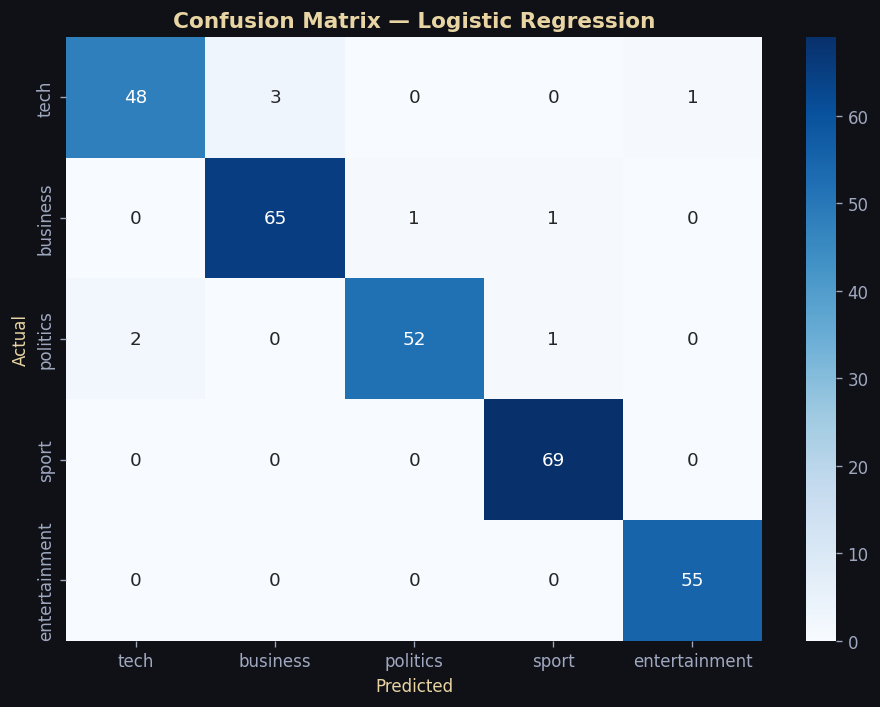

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr, labels=CATEGORIES)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CATEGORIES, yticklabels=CATEGORIES,
            annot_kws={'size':11})
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png',bbox_inches='tight',dpi=150,facecolor='#0f1117')
plt.show()


In [ ]:
# Confidence scores per prediction
proba_lr   = logreg.predict_proba(X_test)
confidences = proba_lr.max(axis=1)
print(f'Mean confidence : {confidences.mean():.3f}')
print(f'Min  confidence : {confidences.min():.3f}')
print(f'Max  confidence : {confidences.max():.3f}')

# Show low-confidence predictions
test_df = df_final.iloc[df_final.index.isin(range(len(df_final)))].copy()
low_conf_idx = confidences.argsort()[:5]
print('\nLow-confidence predictions:')
for i in low_conf_idx:
    print(f'  True: {y_test[i]:<15} Pred: {y_pred_lr[i]:<15} Conf: {confidences[i]:.3f}')


Mean confidence : 0.690
Min  confidence : 0.232
Max  confidence : 0.941

Low-confidence predictions:
  True: politics        Pred: tech            Conf: 0.232
  True: entertainment   Pred: entertainment   Conf: 0.256
  True: business        Pred: business        Conf: 0.274
  True: tech            Pred: entertainment   Conf: 0.284
  True: entertainment   Pred: entertainment   Conf: 0.320


## 2.6 — Save Models to data/models/

In [ ]:
import os

# Define the directory path for models
MODEL_DIR = f'{PROJECT}/data/models/'

# Create the directory if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

# Save classifier
joblib.dump(logreg,     f'{MODEL_DIR}/classifier.pkl')
joblib.dump(tfidf_vec,  f'{MODEL_DIR}/tfidf_vectorizer.pkl')
joblib.dump(count_vec,  f'{MODEL_DIR}/count_vectorizer.pkl')

# Save label mapping
import json
label_info = {
    'categories':     CATEGORIES,
    'model_type':     'LogisticRegression',
    'accuracy':       round(float(acc_lr), 4),
    'cv_mean':        round(float(cv_lr.mean()), 4),
    'cv_std':         round(float(cv_lr.std()), 4),
    'n_train':        int(X_train.shape[0]),
    'n_test':         int(X_test.shape[0]),
    'vocab_size':     int(len(tfidf_vocab)),
}
with open(f'{MODEL_DIR}/model_info.json','w') as f:
    json.dump(label_info, f, indent=2)

print('Models saved to data/models/:')
print('  classifier.pkl')
print('  tfidf_vectorizer.pkl')
print('  count_vectorizer.pkl')
print('  model_info.json')
print(f'\nModel accuracy: {acc_lr:.4f}')

Models saved to data/models/:
  classifier.pkl
  tfidf_vectorizer.pkl
  count_vectorizer.pkl
  model_info.json

Model accuracy: 0.9698


In [ ]:
# ── Verify saved models load correctly ──────────────────────────
clf_loaded = joblib.load(f'{PROJECT}/data/models/classifier.pkl')
vec_loaded  = joblib.load(f'{PROJECT}/data/models/tfidf_vectorizer.pkl')

test_article = 'Apple unveiled its new AI chip at the annual developer conference.'
X_new = vec_loaded.transform([test_article])
pred  = clf_loaded.predict(X_new)[0]
conf  = clf_loaded.predict_proba(X_new).max()

print(f'Test article : {test_article}')
print(f'Predicted    : {pred}')
print(f'Confidence   : {conf:.3f}')
print('\nModel verification successful.')


Test article : Apple unveiled its new AI chip at the annual developer conference.
Predicted    : tech
Confidence   : 0.238

Model verification successful.


## 2.7 — Sentiment Distribution

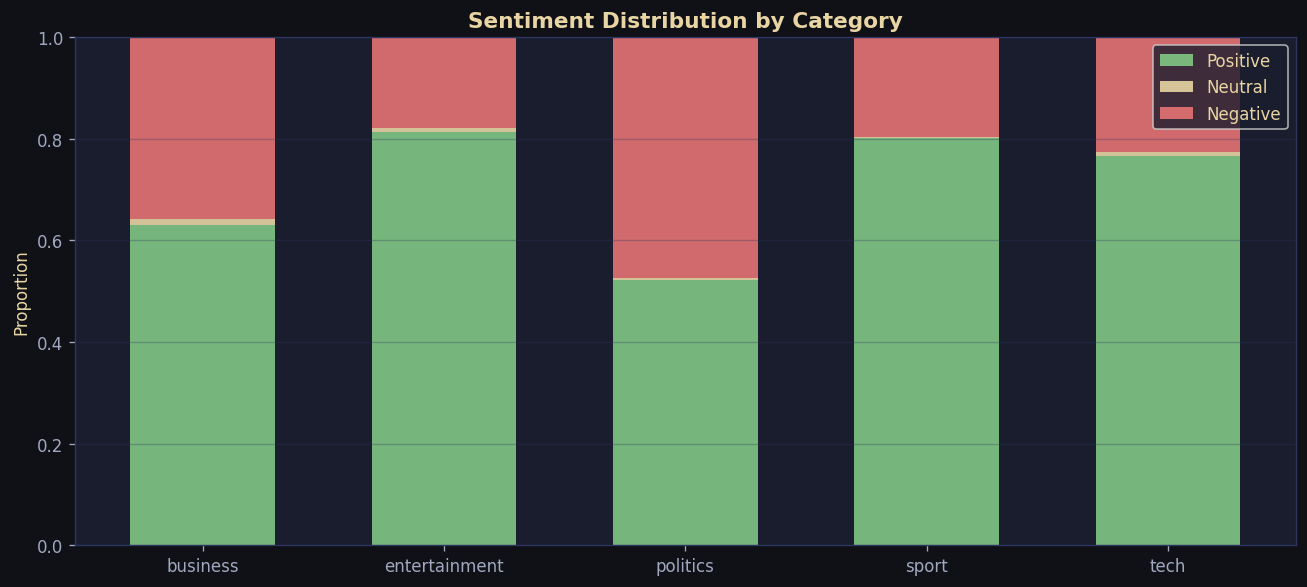

In [ ]:
import matplotlib.pyplot as plt
ct = pd.crosstab(df_final['Category'], df_final['sentiment_label'], normalize='index')
sentiment_colors = {'Positive':'#81c784','Neutral':'#e8d5a3','Negative':'#e57373'}

fig, ax = plt.subplots(figsize=(11,5))
bottoms = np.zeros(len(ct))
for label in ['Positive','Neutral','Negative']:
    if label in ct.columns:
        ax.bar(ct.index, ct[label], bottom=bottoms,
               color=sentiment_colors[label], alpha=0.9, label=label, width=0.6)
        bottoms += ct[label].values

ax.set_title('Sentiment Distribution by Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Proportion'); ax.set_ylim(0,1)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_distribution.png',bbox_inches='tight',dpi=150,facecolor='#0f1117')
plt.show()


In [ ]:
print('='*55)
print('  MODULE 02 SUMMARY')
print('='*55)
print(f'  Articles processed : {len(df_final):,}')
print(f'  Vocabulary size    : {len(tfidf_vocab):,}')
print(f'  Classifier         : Logistic Regression')
print(f'  Test accuracy      : {acc_lr:.4f}')
print(f'  5-Fold CV accuracy : {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')
print(f'  Saved models       : data/models/')
print('='*55)


  MODULE 02 SUMMARY
  Articles processed : 1,490
  Vocabulary size    : 5,000
  Classifier         : Logistic Regression
  Test accuracy      : 0.9698
  5-Fold CV accuracy : 0.9758 +/- 0.0081
  Saved models       : data/models/


In [ ]:
# ── Save df_final for next notebook ──────────────────────────────
df_final.to_pickle(f'{PROJECT}/data/processed/df_final.pkl')
print(f'Saved df_final: {df_final.shape} → {PROJECT}/data/processed/df_final.pkl')
print(f'Columns: {list(df_final.columns)}')

Saved df_final: (1490, 12) → /content/data/MyDrive/ITAI2373-NewsBot-Final/data/processed/df_final.pkl
Columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id', 'cleaned_text', 'entities', 'sentiment_compound', 'sentiment_label', 'passive_voice_instance_count', 'top_tfidf']
